
---

# ⚠️ Bilan Technique : Analyse de la Redondance et de la Frontière de Données

L'analyse des logs d'entraînement a révélé un défaut d'indexation lors des reprises de checkpoints.
**Problème identifié :** Le `grad_accum_steps` (4) consommait les données 4 fois plus vite que l'incrémentation du compteur de `steps` dans les logs. Lors d'une reprise, le `Provider` repartait du numéro de step sans le multiplier par 4, créant un "effet élastique" (retour en arrière systématique).

### 1. Historique des Runs et Consommation Réelle

Chaque run est calculé selon la formule :

* **Index de départ réel** : `Mega-Step Début * 32 * 256`
* **Frontière atteinte par le run** : `(Mega-Step Début + (Delta Steps * 4)) * 32 * 256`

| Fichier | Mega-Step Début | Mega-Step Fin | Delta Steps | Tokens vus (Progression réelle) |
| --- | --- | --- | --- | --- |
| **01** | 0 | 3 300 | 3 300 | 108 134 400 |
| **02** | 3 300 | 14 400 | 11 100 | 471 859 200 |
| **03** | 17 700 | 22 200 | 4 500 | 258 867 200 |
| **05** | 26 100 | 28 800 | 2 700 | 88 473 600 |
| **06** | 28 800 | 35 100 | 6 300 | 511 180 800 |
| **07** | 37 200 | 41 400 | 4 200 | 442 368 000 |
| **Training** | 41 400 | 43 800 | 2 400 | 437 452 800 |

### 2. Stratification du Dataset (Mille-feuille de données)

Le recoupement des données montre une lecture hétérogène du premier tiers du dataset.

| Segment (Tokens) | Segment (MB) | Lectures | Statut |
| --- | --- | --- | --- |
| **0 à 27 M** | 0 - 27 MB | **1 fois** | Lu par le Run 01 uniquement. |
| **27 M à 108 M** | 27 - 108 MB | **2 fois** | Fin du 01 + Début du 02. |
| **108 M à 145 M** | 108 - 145 MB | **1 fois** | Suite du 02 (zone sautée par le Run 03). |
| **145 M à 213 M** | 145 - 213 MB | **2 fois** | Milieu du 02 + Début du 03. |
| **213 M à 235 M** | 213 - 235 MB | **3 fois** | Run 02 + Run 03 + Début du 06. |
| **235 M à 302 M** | 235 - 302 MB | **4 fois** | **Zone critique : redondance maximale.** |
| **302 M à 403 M** | 302 - 403 MB | **3 fois** | Run 02 + Run 03 + Run 06. |
| **403 M à 498 M** | 403 - 498 MB | **2 fois** | Run 02 + Run 06. |
| **498 M à 511 M** | 498 - 511 MB | **1 fois** | **Frontière historique maximale.** |
| **511 M à 1 526 M** | **511 MB - 1.5 GB** | **0 fois** | **Zone Inconnue (Jamais lue).** |

### 3. Conclusion du Diagnostic

L'entraînement a stagné en raison d'une **exploration incomplète et répétitive** :

* **Exploration réelle** : Seuls **511 MB** sur les **1 526 MB** disponibles ont été parcourus (33.48%).
* **Conséquence** : Le modèle a "rabâché" les mêmes séquences, provoquant une stagnation de la Loss par manque de nouveauté informationnelle.
* **Correction** : Le passage au `DeterministicProvider` corrigé (`step * grad_accum_steps`) assure désormais une lecture linéaire de 100% du dataset sans redondance.

---
# Au final en relançant avec la version modifée de Deterministic le modèle commencera à voir des données à partir du step **15600**.

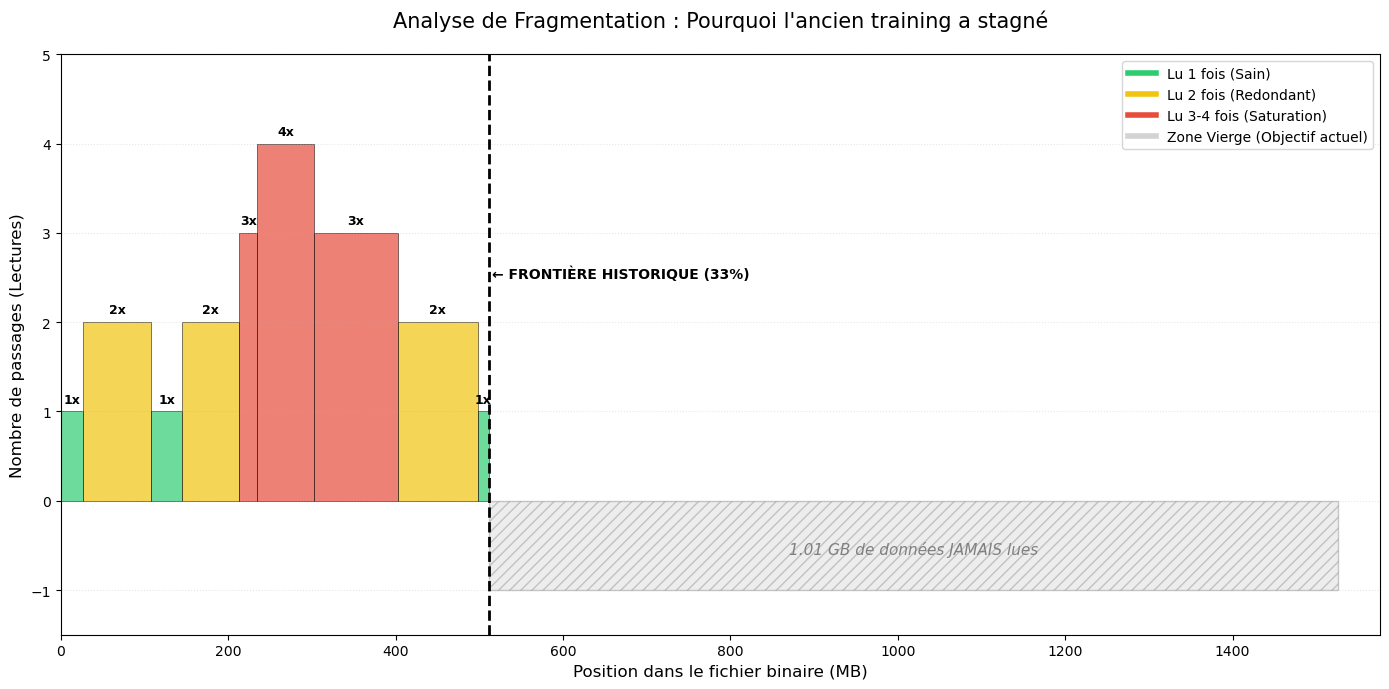

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Configuration du Dataset (1.526 GB)
total_mb = 1526  

# Définition des zones (Début_MB, Fin_MB, Nombre_de_lectures)
zones = [
    (0, 27, 1),      # Run 01
    (27, 108, 2),    # Run 01 + 02
    (108, 145, 1),   # Run 02 seul
    (145, 213, 2),   # Run 02 + 03
    (213, 235, 3),   # Run 02 + 03 + 06
    (235, 302, 4),   # Zone de sur-apprentissage
    (302, 403, 3),   # Run 02 + 03 + 06
    (403, 498, 2),   # Run 02 + 06
    (498, 511, 1),   # Frontière historique
]

plt.figure(figsize=(14, 7))

# 1. Tracer les zones explorées (0 à 511 MB)
for start, end, counts in zones:
    if counts == 1:
        color = '#2ecc71' # Vert
    elif counts == 2:
        color = '#f1c40f' # Jaune/Orange
    else:
        color = '#e74c3c' # Rouge
        
    plt.fill_between([start, end], [0, 0], [counts, counts], 
                     color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
    
    plt.text((start + end) / 2, counts + 0.1, f"{counts}x", 
             ha='center', fontsize=9, fontweight='bold')

# 2. Tracer la zone VIERGE (511 MB à 1526 MB) à y = -1
# Correction : on dessine un bloc entre y=0 et y=-1
plt.fill_between([511, total_mb], [-1, -1], [0, 0], 
                 color='lightgray', alpha=0.4, hatch='///', edgecolor='gray')

# 3. Cosmétique et annotations
plt.axvline(x=511, color='black', linestyle='--', linewidth=2)
plt.text(515, 2.5, "← FRONTIÈRE HISTORIQUE (33%)", rotation=0, fontweight='bold', color='black')

# Correction de l'erreur : fontstyle='italic' au lieu de fontweight='italic'
plt.text((511 + total_mb)/2, -0.6, "1.01 GB de données JAMAIS lues", 
         ha='center', fontsize=11, color='gray', fontstyle='italic')

plt.title("Analyse de Fragmentation : Pourquoi l'ancien training a stagné", fontsize=15, pad=20)
plt.xlabel("Position dans le fichier binaire (MB)", fontsize=12)
plt.ylabel("Nombre de passages (Lectures)", fontsize=12)
plt.xlim(0, total_mb + 50)
plt.ylim(-1.5, 5) 

# Légende
legend_elements = [
    Line2D([0], [0], color='#2ecc71', lw=4, label='Lu 1 fois (Sain)'),
    Line2D([0], [0], color='#f1c40f', lw=4, label='Lu 2 fois (Redondant)'),
    Line2D([0], [0], color='#e74c3c', lw=4, label='Lu 3-4 fois (Saturation)'),
    Line2D([0], [0], color='lightgray', lw=4, label='Zone Vierge (Objectif actuel)')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()